# Diffusion Prior on PROBES + Caustic Lensing

Train a score-based diffusion prior on a small subset of `gals_gband_norm`, then use it as a galaxy-image prior together with `caustic`'s strong-lensing forward model.

Stack:
- `torch` – tensors, autograd, GPU
- [`score_models`](https://github.com/AlexandreAdam/score_models) – NCSN++ + VE-SDE training & sampling
- [`caustics`](https://github.com/Ciela-Institute/caustics) – differentiable strong-lensing simulator

Pipeline:
1. Load a small subset of preprocessed PROBES g-band images.
2. Train an NCSN++ score model with a VE SDE (the architecture used by Adam et al. 2023).
3. Sample from the learned galaxy prior.
4. Build a `caustics` SIE strong-lens simulator and forward-lens a sampled source.
5. Posterior sampling: combine the diffusion prior with the lensing likelihood to reconstruct a source from a noisy lensed observation.

In [11]:
# salloc -t 02:00:00 --nodes=1 --gres=gpu:3 --ntasks-per-node=1 --cpus-per-task=3 --partition=ampere -A mphil-dis-sl2-gpu jupyter notebook --no-browser --ip=* --port=8081

## 1. Imports & device

In [12]:
import os, glob, math, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from score_models import ScoreModel, NCSNpp
import caustics

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('torch', torch.__version__, '| caustics', caustics.__version__, '| device', device)

torch.manual_seed(21)
np.random.seed(21)

torch 2.10.0+cu128 | caustics 1.6.0 | device cuda


## 2. Configuration

In [13]:
# Anchor paths to the project root so the notebook works regardless of cwd.
PROJECT_ROOT   = Path('/home/yd388/rds/hpc-work/DIS-Project-Lensed-Galaxy')
DATA_PATH      = PROJECT_ROOT / 'data' / 'gals_gband_norm'
OUTPUT_DIR     = PROJECT_ROOT / 'outputs' / 'probes_diffusion'

N_SUBSET       = 64        # small subset for quick experimentation
IMAGE_SIZE     = 128       # downsample 256 -> 128 for speed

# NCSN++ / VE-SDE hyperparameters (mirroring Adam et al. 2023)
NF             = 128
CH_MULT        = [2, 2, 2, 2]
SIGMA_MIN      = 1e-4
SIGMA_MAX      = -1        # -1 -> auto-estimate from data pairwise distance

# Training
EPOCHS         = 200
BATCH_SIZE     = 8
LR             = 2e-4

# Sampling
SAMPLE_STEPS   = 1000
N_SAMPLES      = 8

os.makedirs(OUTPUT_DIR, exist_ok=True)

## 3. Load and preprocess a small subset

In [14]:
def load_probes(path, n_subset=None, image_size=128, seed=42):
    """Load already-preprocessed PROBES g-band .npy files.

    Files in ``data/gals_gband_norm`` were produced by ``data/preprocess.py``:
    each is shape (1, 256, 256), float32, values in [-1, 1] (asinh-style
    truncation + min-max per Smith et al. 2022 §3.1).

    Returns a float32 array of shape (N, image_size, image_size) in [0, 1],
    ready to be wrapped by GalaxyDataset.
    """
    rng = np.random.RandomState(seed)
    files = sorted(glob.glob(str(Path(path) / '*.npy')))
    if not files:
        raise FileNotFoundError(f'No .npy files in {path}')

    if n_subset and n_subset < len(files):
        files = [files[i] for i in rng.choice(len(files), n_subset, replace=False)]

    raw = np.stack([np.load(f) for f in files]).astype(np.float32)
    if raw.ndim == 4:           # (N, 1, H, W) -> drop channel dim
        raw = raw[:, 0]
    print(f'Loaded: {raw.shape}, range=[{raw.min():.4g}, {raw.max():.4g}]')

    # Data is already normalized to [-1, 1] by data/preprocess.py;
    # rescale to [0, 1] for the rest of the pipeline.
    images = (raw + 1.0) / 2.0

    if images.shape[1] != image_size or images.shape[2] != image_size:
        from PIL import Image as PILImage
        images = np.array([
            np.array(PILImage.fromarray(img, mode='F')
                     .resize((image_size, image_size), PILImage.LANCZOS))
            for img in images
        ], dtype=np.float32)
        print(f'Resized to {image_size}x{image_size}')

    images = np.clip(images, 0.0, 1.0).astype(np.float32)
    print(f'Final: {images.shape}, range=[{images.min():.4f}, {images.max():.4f}]')
    return images

Loaded: (64, 256, 256), range=[-1, 1]
Resized to 128x128
Final: (64, 128, 128), range=[0.0000, 1.0000]


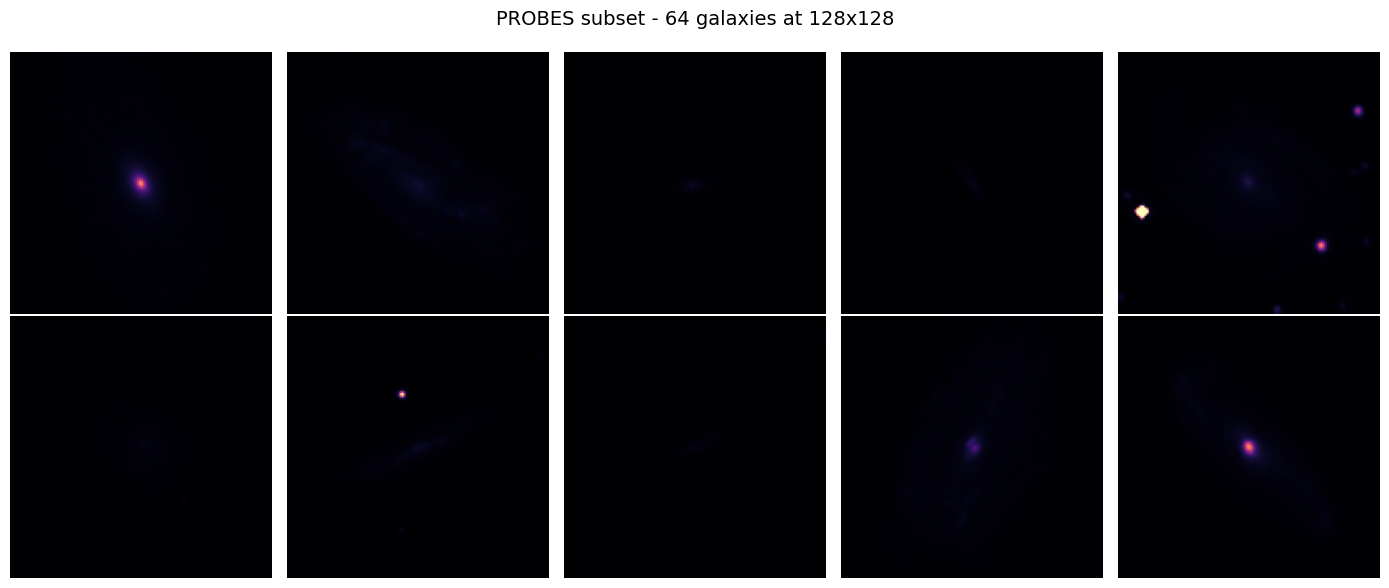

In [15]:
images = load_probes(DATA_PATH, n_subset=N_SUBSET, image_size=IMAGE_SIZE)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i], cmap='magma', origin='lower', vmin=0, vmax=1)
    ax.axis('off')
fig.suptitle(f'PROBES subset - {N_SUBSET} galaxies at {IMAGE_SIZE}x{IMAGE_SIZE}', fontsize=14)
plt.tight_layout(); plt.show()

In [16]:
class GalaxyDataset(Dataset):
    """(N, 1, H, W) tensors in [0, 1], pre-moved to ``device``."""
    def __init__(self, images, device=None):
        t = torch.from_numpy(images).float().unsqueeze(1)
        self.images = t.to(device) if device is not None else t

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx]


# Pre-move to device so score_models.fit (which does not auto-transfer) sees
# data on the same device as the model.
dataset = GalaxyDataset(images, device=device)
print('Dataset:', len(dataset), 'tensor shape:', dataset.images.shape, 'device:', dataset.images.device)

Dataset: 64 tensor shape: torch.Size([64, 1, 128, 128]) device: cuda:0


## 4. Build the score-based diffusion model (NCSN++ + VE-SDE)

In [17]:
# Auto-estimate sigma_max from data pairwise distances (Song & Ermon 2020 heuristic).
if SIGMA_MAX < 0:
    flat = dataset.images.view(len(dataset), -1)
    if len(flat) <= 500:
        sigma_max = torch.cdist(flat, flat).max().item()
    else:
        rng = np.random.RandomState(0)
        pairs = rng.randint(0, len(flat), (5000, 2))
        sigma_max = max((flat[i] - flat[j]).norm().item() for i, j in pairs)
else:
    sigma_max = SIGMA_MAX
print(f'VE SDE: sigma_min={SIGMA_MIN:.1e}, sigma_max={sigma_max:.2f}')

VE SDE: sigma_min=1.0e-04, sigma_max=8.31


In [18]:
net = NCSNpp(
    channels=1,         # grayscale g-band
    nf=NF,              # base feature count
    ch_mult=CH_MULT,    # channel multipliers per resolution
    dimensions=2,       # 2D images
)

model = ScoreModel(
    model=net,
    sigma_min=SIGMA_MIN,
    sigma_max=sigma_max,
    device=device,
)
n_params = sum(p.numel() for p in model.parameters())
print(f'NCSN++: {n_params:,} parameters')

Using the Variance Exploding SDE
NCSN++: 45,820,996 parameters


## 5. Train the prior

`ScoreModel.fit` handles denoising-score-matching with a VE SDE under the hood and writes checkpoints to `OUTPUT_DIR`.

In [19]:
model.fit(
    dataset,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LR,
    checkpoints_directory=str(OUTPUT_DIR),  # score_models JSON-dumps kwargs, so Path -> str
    seed=21,
)

Loaded checkpoint 22 of probes_diffusion


Epoch 200 | Cost: 2.5e+03 |: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [06:00<00:00,  1.80s/it]

Finished training after 0.100 hours.


[1696.4097509384155,
 1369.7644233703613,
 660.840461730957,
 1845.3174266815186,
 2189.3130416870117,
 1277.9140014648438,
 1289.352439880371,
 1563.4682846069336,
 1816.5461730957031,
 1725.5282592773438,
 2066.4324951171875,
 1032.954236984253,
 1918.4774017333984,
 1205.7254638671875,
 2200.299966812134,
 1930.2923583984375,
 1731.3843040466309,
 947.162661075592,
 1969.3386001586914,
 1305.1817932128906,
 1854.4374237060547,
 1869.9605083465576,
 1864.2152252197266,
 1170.8082122802734,
 1312.608528137207,
 659.0357875823975,
 1733.0048065185547,
 1840.8016357421875,
 2242.588333129883,
 2223.904354095459,
 1529.1830520629883,
 1196.7706747055054,
 1139.9152908325195,
 1611.7031631469727,
 1501.7777118682861,
 2081.0883445739746,
 1631.7686157226562,
 1859.5627193450928,
 1482.7812576293945,
 826.3642616271973,
 1840.1126022338867,
 1739.95804977417,
 1876.7312183380127,
 976.760684967041,
 1520.2237529754639,
 1364.6237316131592,
 1304.894515991211,
 1774.8604526519775,
 2058.209

## 6. Sample from the learned galaxy prior

Sampling from the prior | t = 0.0 | sigma = 1.0e-04| scale ~ 5.8e-02: 100%|██████████████████████████████████████████████████████████████████████| 1000/1000 [01:12<00:00, 13.81it/s]


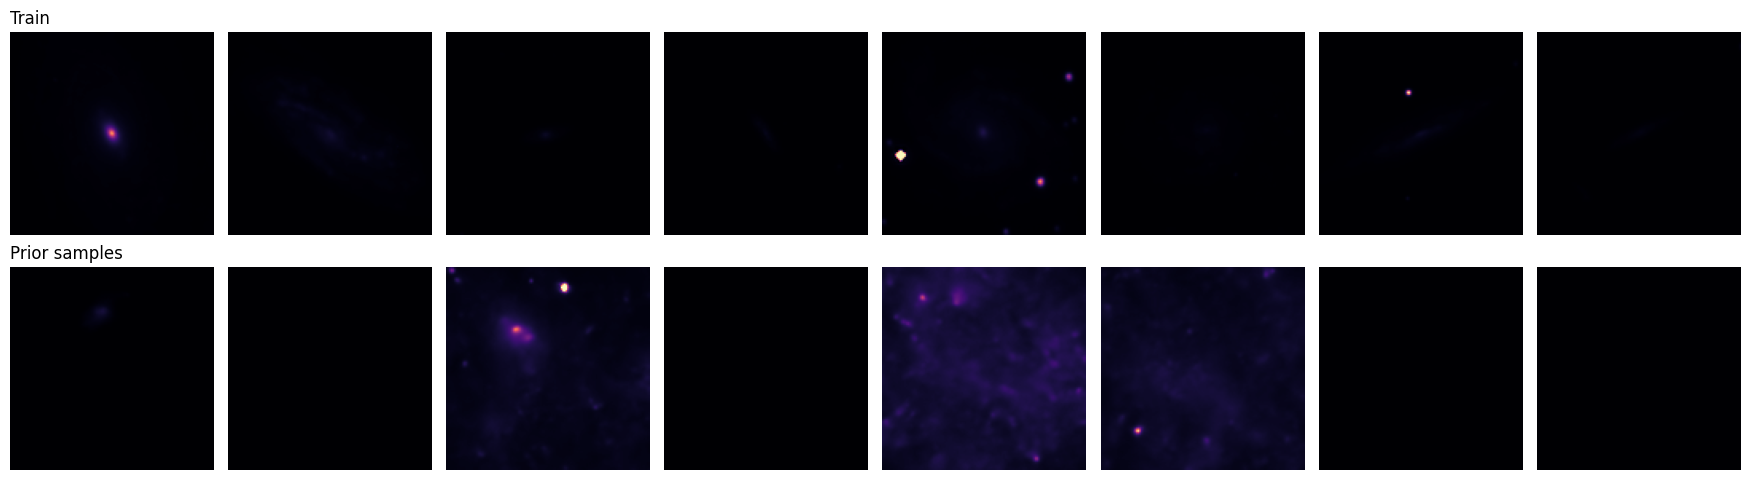

In [20]:
with torch.no_grad():
    samples = model.sample(
        shape=[N_SAMPLES, 1, IMAGE_SIZE, IMAGE_SIZE],
        steps=SAMPLE_STEPS,
    )
samples = samples.clamp(0, 1).cpu()
# Save into a sibling subdir; score_models.fit() scans OUTPUT_DIR/*.pt as
# checkpoints and chokes on filenames without digits.
SAMPLES_DIR = OUTPUT_DIR / 'samples'
SAMPLES_DIR.mkdir(parents=True, exist_ok=True)
torch.save(samples, SAMPLES_DIR / 'samples_prior.pt')

fig, axes = plt.subplots(2, N_SAMPLES, figsize=(2.2 * N_SAMPLES, 5))
for i in range(N_SAMPLES):
    axes[0, i].imshow(images[i % len(images)], cmap='magma', origin='lower', vmin=0, vmax=1)
    axes[0, i].axis('off')
    axes[1, i].imshow(samples[i, 0].numpy(), cmap='magma', origin='lower', vmin=0, vmax=1)
    axes[1, i].axis('off')
axes[0, 0].set_title('Train', loc='left')
axes[1, 0].set_title('Prior samples', loc='left')
plt.tight_layout(); plt.show()

## 7. Caustic strong-lensing forward model

We use a Singular Isothermal Ellipsoid (SIE) main deflector and a `Pixelated` source whose pixels are the galaxy image. `LensSource` is fully differentiable in PyTorch so it composes naturally with the diffusion prior.

In [21]:
# Image-plane geometry
PIXELSCALE = 0.04           # arcsec/pixel (HST-like)
PIXELS     = IMAGE_SIZE     # square image of same size as the source
Z_LENS     = 0.5
Z_SOURCE   = 1.5

cosmology = caustics.FlatLambdaCDM(name='cosmo')

# caustics 1.6: z_s lives on the lens; Einstein radius is `Rein` (was `b`).
lens = caustics.SIE(
    cosmology=cosmology,
    name='lens',
    z_l=Z_LENS,
    z_s=Z_SOURCE,
    x0=0.0, y0=0.0,
    q=0.7,                  # axis ratio
    phi=math.pi / 6,        # position angle
    Rein=1.2,               # Einstein radius (arcsec)
)

# Pixelated source - pixels filled in at call time from a torch image
source = caustics.Pixelated(
    name='source',
    x0=0.0, y0=0.0,
    pixelscale=PIXELSCALE,
    shape=(IMAGE_SIZE, IMAGE_SIZE),
)

sim = caustics.LensSource(
    lens=lens,
    source=source,
    pixelscale=PIXELSCALE,
    pixels_x=PIXELS,
    pixels_y=PIXELS,
    name='sim',
)
sim.to(device)   # caskade supports .to(); aligns SIE/Pixelated params with the input image device
print(sim)

sim|LensSource
    psf|static: 1
    x0|static: 0
    y0|static: 0
    lens|SIE
        cosmo|FlatLambdaCDM
            h0|static: 0.677
            critical_density_0|static: 1.27e+11
            Om0|static: 0.31
        z_s|static: 1.5
        z_l|static: 0.5
        x0|static: 0
        y0|static: 0
        q|static: 0.7
        phi|static: 0.524
        Rein|static: 1.2
    source|Pixelated
        x0|static: 0
        y0|static: 0
        image|dynamic
        pixelscale|static: 0.04
        scale|static: 1


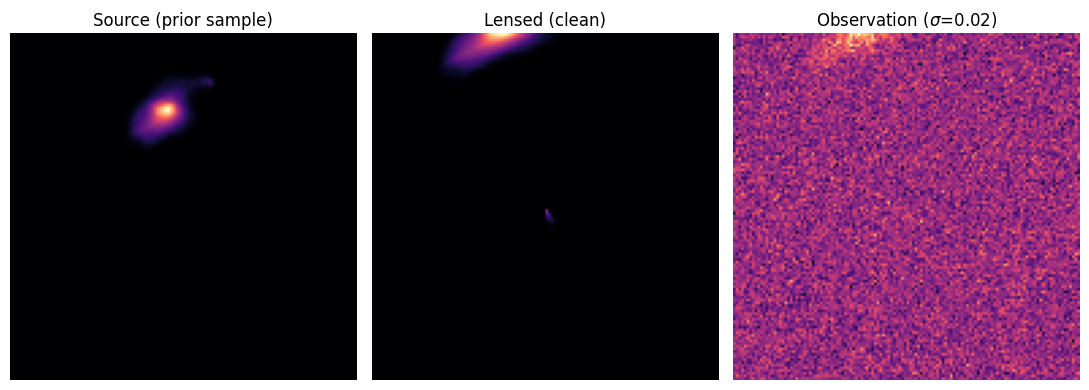

In [22]:
# Take one prior sample as the source and lens it.
src_img = samples[0, 0].to(device)              # (H, W) tensor in [0, 1]
params = {'source': {'image': src_img}}         # only the pixel image is unspecified above

with torch.no_grad():
    lensed = sim(params)

# Add Gaussian observational noise
NOISE_SIGMA = 0.02
obs = lensed + NOISE_SIGMA * torch.randn_like(lensed)

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
axes[0].imshow(src_img.cpu(), cmap='magma', origin='lower'); axes[0].set_title('Source (prior sample)')
axes[1].imshow(lensed.cpu(),  cmap='magma', origin='lower'); axes[1].set_title('Lensed (clean)')
axes[2].imshow(obs.cpu(),     cmap='magma', origin='lower'); axes[2].set_title(f'Observation ($\\sigma$={NOISE_SIGMA})')
for a in axes: a.axis('off')
plt.tight_layout(); plt.show()

## 8. Posterior sampling: convolved-likelihood reverse SDE (Adam et al. 2022)

Given a noisy lensed observation $y = A x + \eta$ with $\eta \sim \mathcal{N}(0, \sigma_y^2 I)$, we want samples from $p(x \mid y) \propto p(y \mid x)\,p(x)$.

Following Adam et al. 2022 (§2.2 + Appendix A), we approximate the time-marginal likelihood by **convolving** it with the diffusion noise schedule (eq. 19):
$$ p_t(y \mid x_t) \approx \mathcal{N}\!\left(y \,\big|\, A x_t,\; (\sigma_y^2 + \sigma^2(t)) I\right) $$
so the conditional score (eq. 5) becomes
$$ \nabla_{x_t} \log p_t(x_t \mid y) \;\approx\; s_\theta(x_t, t) \;+\; \frac{A^\top (y - A x_t)}{\sigma_y^2 + \sigma^2(t)}. $$

Unlike DPS, this **does not** use Tweedie's mean — we evaluate $A$ directly at the noisy $x_t$, with the inflated noise covariance absorbing the diffusion uncertainty. We then solve the reverse-time VE SDE with Euler-Maruyama (eq. 20):
$$ x_{t-h} = x_t + g^2(t)\,\nabla_{x_t}\log p_t(x_t\mid y)\,h + g(t)\,\sqrt{h}\,z, \quad z\sim\mathcal{N}(0, I). $$

$A^\top$ is obtained for free by autograd through the (differentiable) `caustics` simulator. Paper uses $N = 8000$ steps; we use a smaller $N$ here for speed.

In [ ]:
@torch.no_grad()
def posterior_sample(model, sim, y, sigma_y, steps=2000, n_samples=4):
    """Convolved-likelihood posterior sampler (Adam et al. 2022, eqs. 19, 20).

    At each Euler-Maruyama step on the reverse VE-SDE, the posterior score is

        s_theta(x_t, t)  +  A^T (y - A x_t) / (sigma_y^2 + sigma^2(t))

    where A is the (differentiable) caustics lensing operator. A^T is computed
    by autograd; we never form A explicitly.

    model     : trained ScoreModel (VE-SDE)
    sim       : caustics.LensSource forward operator (callable: image -> lensed)
    y         : observed lensed image (H, W) on device
    sigma_y   : observational noise std
    steps     : number of Euler-Maruyama discretizations (paper uses 8000)
    n_samples : independent posterior draws
    """
    device = next(model.parameters()).device
    H = W  = y.shape[-1]
    sde    = model.sde

    # Descending time grid t in [1, ~0]; positive step h = t_i - t_{i+1}.
    t_grid = torch.linspace(1.0, 1e-3, steps + 1, device=device)

    # Initialize at t=1 from the SDE prior (~ N(0, sigma_max^2 I) for VE SDE).
    x = sde.prior([n_samples, 1, H, W]).sample().to(device)

    for i in range(steps):
        t_scalar = t_grid[i]
        t_batch  = t_scalar.expand(n_samples)
        h        = (t_grid[i] - t_grid[i + 1])             # positive
        var      = sigma_y ** 2 + sde.sigma(t_scalar) ** 2  # convolved-likelihood variance
        g        = sde.diffusion(t_batch, x)                # g(t)

        # Convolved-likelihood gradient via autograd through caustics.
        with torch.enable_grad():
            x_req = x.detach().requires_grad_(True)
            preds = torch.stack([sim({'source': {'image': x_req[b, 0]}})
                                 for b in range(n_samples)])
            log_lik = -0.5 * ((y - preds) ** 2).sum() / var
            grad_ll = torch.autograd.grad(log_lik, x_req)[0]

        # Conditional score: prior + convolved-likelihood gradient.
        score_post = model.score(t_batch, x) + grad_ll

        # Euler-Maruyama on the reverse VE-SDE (paper eq. 20).
        z = torch.randn_like(x)
        x = x + (g ** 2) * score_post * h + g * z * h.sqrt()

    return x.clamp(0, 1)

In [ ]:
post = posterior_sample(
    model, sim,
    y=obs.to(device),
    sigma_y=NOISE_SIGMA,
    steps=SAMPLE_STEPS,
    n_samples=4,
).cpu()

fig, axes = plt.subplots(1, 6, figsize=(18, 3.2))
axes[0].imshow(src_img.cpu(), cmap='magma', origin='lower'); axes[0].set_title('True source')
axes[1].imshow(obs.cpu(),     cmap='magma', origin='lower'); axes[1].set_title('Observation')
for k in range(4):
    axes[2 + k].imshow(post[k, 0], cmap='magma', origin='lower')
    axes[2 + k].set_title(f'Posterior {k}')
for a in axes: a.axis('off')
plt.tight_layout(); plt.show()

### Notes on paper alignment
- **Sampler**: now matches Adam et al. 2022 §2.2 + Appendix A (convolved likelihood, eq. 19; Euler-Maruyama, eq. 20). The earlier DPS-style version used Tweedie's mean and unmodified $\sigma_y^2$; the paper does neither.
- **Steps $N$**: paper uses 8000 (Appendix B); bump `SAMPLE_STEPS` accordingly when running the final reproduction.
- **Lens model**: paper uses SIE **plus external shear**; here we use SIE only. Add `caustics.ExternalShear` and combine via `caustics.SinglePlane` for full fidelity.
- **Resolution**: paper trains the source at 256 and pixelates the lensed observation at 128 (2× average pool). Here we use 128 throughout for subset speed.
- **Subset training**: `N_SUBSET=64` and `EPOCHS=200` give a quick sanity check; for paper-quality samples, train on the full ~2000-galaxy set with the paper's batch=16 and ~350k steps.